In [1]:
from pyCHX.chx_packages import *
plt.rcParams.update({'figure.max_open_warning': 0})
plt.rcParams.update({ 'image.origin': 'lower'   })
plt.rcParams.update({ 'image.interpolation': 'none'   })
import itertools
from copy import deepcopy
import json
from termcolor import colored
%run /nsls2/data/chx/shared/CHX_Software/packages/environment_management/chx_analysis_setup.ipynb

OBJECT CACHE: Will use up to 121_499_065_958 bytes (15% of total physical RAM)
/nsls2/conda/envs/2024-1.0-py311-tiled-rc1/lib/python3.11/site-packages/databroker/v1.py:72: UserWarning: In databroker 2.x, there are separate notions of 'server' and 'client', and register_handler(...) has no effect on the client. Likely this is being done for you on the server side, so you should not worry about this message unless you encounter trouble loading large array data.
  warnings.warn(


running on: jupyter_hub   environment: standard

setting '_base_path_' as /nsls2/data/chx/legacy/analysis/
setting '_mask_path_' as /nsls2/data/chx/shared/CHX_Setup/Detector_masks/

ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/roi_nr_2019_3_0_1.py" to fix ROI numbering for PHI-sliced data sets. Should get fixed in pyCHX...
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/chx_outlier_detection.py": this should become part of pyCHX.
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/fix_get_sid_filenames.py": this should be fixed and re-deployed in pyCHX.

environment dependent settings and patches:
using "%matplotlib inline" for plotting
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/patches/polygonmask_fix.py".
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_compress.py": temporary fix for depreciated np.float.
ran "%run -i /nsls2/data/chx/shared/CHX_Software/packages/pyCHX/chx_correlationc.py": tempora

In [3]:
mask_selection = 'super_wide'  # select a mask to create, NOTE: if this is a new mask, need to enter parameters in mask_param_dict first!


mask_param_dict={'phi_12x30_rot45_fineQ':
                 {'flow_geometry':False,'inner_radius':24,'outer_radius':4000,'num_rings':150,'gap_ring_number':1,'width':'auto','edges':None,
                 'ang_centers':np.array([15,45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345 ])-180,'ang_width':30-.01,
                 'inner_angle':None,'outer_angle':None,'num_angles':None,'comment':'12x30deg phi-segments, rotated 45deg, i.e. there is e.g. a segment centered around 45deg, smaller Q-rings than "12x30_rot45"'},
                
                 'phi_4x20deg':
                 {'flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':65,'gap_ring_number':1,'width':'auto','edges':None,
                 'ang_centers':np.array([0,90,180,270])-180,'ang_width':20-.01,
                 'inner_angle':-10,'outer_angle':350,'num_angles':None,'comment':'12x30deg phi-segments, rotated 45deg, i.e. there is e.g. a segment centered around 45deg, smaller Q-rings than "12x30_rot45"'},
                     
                 'phi_12x30_rot45':
                 {'flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':65,'gap_ring_number':1,'width':'auto','edges':None,
                 'ang_centers':np.array([15,45, 75, 105, 135, 165, 195, 225, 255, 285, 315, 345 ])-180,'ang_width':30-.01,
                 'inner_angle':None,'outer_angle':None,'num_angles':None,'comment':'12x30deg phi-segments, rotated 45deg, i.e. there is e.g. a segment centered around 45deg'},
                 
                 'phi_16x22_5deg':
                 {'flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':65,'gap_ring_number':1,'width':'auto','edges':None,
                 'ang_centers':np.array([  0,  22.5,  45.,  67.5,  90., 112.5, 135., 157.5, 180., 202.5, 225., 247.5, 270., 292.5, 315., 337.5])-180,'ang_width':22.5-.01,
                 'inner_angle':None,'outer_angle':None,'num_angles':None,'comment':'16x22.5deg phi-segments'},
                 
                 'phi_12x15deg_flow':  #  THIS IS JUST AN EXAMPLE, this mask might have never been created
                 {'flow_geometry':True,'inner_radius':10,'outer_radius':4000,'num_rings':65,'gap_ring_number':1,'width':'auto','edges':None,
                 'ang_centers':np.array([  0., 15 ,30, 45.,  60, 75,  90., 105, 120., 135, 150., 165, 180])-180,'ang_width':15-.01,
                 'inner_angle':0,'outer_angle':180,'num_angles':12,'comment':'12x15deg phi-segments, combining centro-symmetric phi-segements'},
                 
                 'super_wide': #  THIS IS JUST AN EXAMPLE for a non Phi-sliced mask, this mask has never been created
                 {'flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':25,'gap_ring_number':1,'width':'auto','edges':None,
                 'ang_centers':None,'ang_width':None,
                 'inner_angle':None,'outer_angle':None,'num_angles':None,'comment':'non-phi-sliced mask with super-wide rings'},
                }

###################################################################################################################################################
if mask_param_dict[mask_selection]['width']=='auto':
    width =    ( mask_param_dict[mask_selection]['outer_radius'] - mask_param_dict[mask_selection]['inner_radius'])/(mask_param_dict[mask_selection]['num_rings'] + mask_param_dict[mask_selection]['gap_ring_number'])
else:
    width = mask_param_dict[mask_selection]['width']

if mask_param_dict[mask_selection]['flow_geometry']:
    ang_edges=None
    ang_width = mask_param_dict[mask_selection]['ang_width']
else:
    try:
        ang_edges = get_non_uniform_edges(  mask_param_dict[mask_selection]['ang_centers'], mask_param_dict[mask_selection]['ang_width'], number_rings=1 ) 
        ang_width = None
    except:
        ang_edges=None
        ang_width=None



### Create the oversized ROI-mask

In [4]:
pixel_num_thres=100  # minimum number of pixels for an ROI (ROIs with smaller number of pixels will be discarded)
sx = 8000  # size of oversized ROI-mask
cen='auto' # center in oversized ROI-maks [x,y] -> recommended: 'auto', which picks the geometrical center
#######################################################################################################################

shape = np.array( [sx,sx] )
if cen == 'auto':
    cen = shape//2
else: 
    assert len(cen)==2, "ERROR: cen must be either 'auto' or a list of the form [x,y]"
    cen=np.array(cen)
m = np.ones( shape )

## update mask_param_dict with this information:
mask_param_dict[mask_selection]['ROI mask size']=sx
mask_param_dict[mask_selection]['original center']=cen
mask_param_dict[mask_selection]['pixel_num_thres']=pixel_num_thres

# 'fake' setup parameters to create Q-mask
setup_pargs0 ={'uid': 'xxx',
 'dpix': 0.07500000356230885,
 'Ldet': 10113.499641418457,
 'lambda_': 1.2846771, 
 'center': cen,
 'path': ''}
 
center = setup_pargs0['center']

#create Q-mask
roi_mask0, qr, qr_edge = get_ring_mask(  m, inner_radius= mask_param_dict[mask_selection]['inner_radius'], 
            outer_radius = mask_param_dict[mask_selection]['outer_radius'] , width = width, num_rings = mask_param_dict[mask_selection]['num_rings'], edges=mask_param_dict[mask_selection]['edges'],
                          unit='pixel',       pargs=setup_pargs0   )

try:
    if mask_param_dict[mask_selection]['ang_centers']==None and mask_param_dict[mask_selection]['ang_width']==None and mask_param_dict[mask_selection]['inner_angle']==None and mask_param_dict[mask_selection]['outer_angle']==None and mask_param_dict[mask_selection]['num_angles']==None:
        geometry='saxs'
        roi_mask0, good_ind = combine_two_roi_mask( roi_mask0, np.ones(np.shape(roi_mask0),dtype=int),pixel_num_thres=pixel_num_thres)  
except:
    geometry='ang_saxs'
    
if geometry=='ang_saxs': #create Phi-mask
    if np.min(ang_edges)<-180. or np.max(ang_edges)>180.:
            fix_180_angle=True
    else: fix_180_angle=False

    roi_mask_ang, ang_center, ang_edge = get_angular_mask( m,  inner_angle= mask_param_dict[mask_selection]['inner_angle'], 
            outer_angle = mask_param_dict[mask_selection]['outer_angle'], width = ang_width, edges = ang_edges,
                    num_angles = mask_param_dict[mask_selection]['num_angles'], center = center, flow_geometry= mask_param_dict[mask_selection]['flow_geometry'],fix_180_angle=fix_180_angle ) 
    # combine Q- and Phi-mask
    roi_mask0, good_ind = combine_two_roi_mask( roi_mask0, roi_mask_ang,pixel_num_thres=pixel_num_thres)   

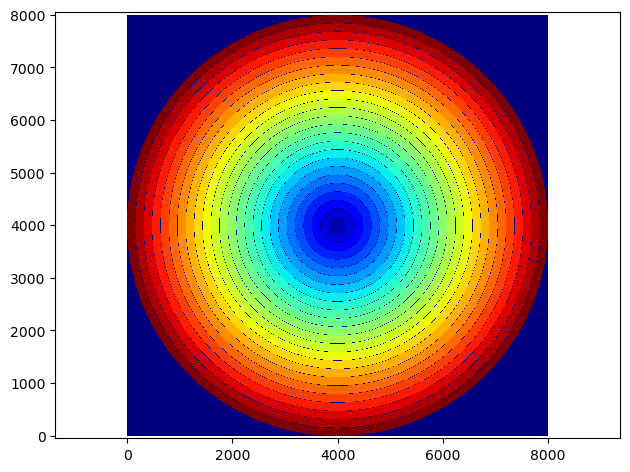

In [5]:
plt.imshow(roi_mask0,cmap='jet')
plt.axis('equal');plt.tight_layout()

In [6]:
# load some real data
uid = 'eef49b53-3ba9-44ea-93a1-9c3613abeb5c' #.01s x200fr membrane on 4M
md = get_meta_data( uid )
limit_qnum = 60 # maximum number of ROIs to create (starts from smalles Q and Phi)

#####################################################################################################
detectors = sorted(get_detectors(db[uid]))
if len(detectors) >1:
    md['detector'] = detectors[1]
    print( md['detector'])
    
if md['detector'] =='eiger4m_single_image' or md['detector'] == 'image':    
    reverse= True
    rot90= False
elif md['detector'] =='eiger500K_single_image':    
    reverse= True
    rot90=True
elif md['detector'] =='eiger1m_single_image':    
    reverse= True
    rot90=False
print('Image reverse: %s\nImage rotate 90: %s'%(reverse, rot90)) 
imgs = load_data( uid, md['detector'], reverse= reverse, rot90=rot90  )
md.update( imgs.md );Nimg = len(imgs);md['number of images']  = Nimg
if reverse and not rot90:
    md['beam_center_y']=np.shape(imgs[0])[0]- md['beam_center_y']
if reverse and rot90:
    xc=md['beam_center_y'];yc=md['beam_center_x']
    yc=np.shape(imgs[0])[0]-yc
    xc=np.shape(imgs[0])[1]-xc
    md['beam_center_y']=yc;md['beam_center_x']=xc
inc_y0 = md['beam_center_y']
inc_x0 = md['beam_center_x']
dpix, lambda_, Ldet,  exposuretime, timeperframe, center = check_lost_metadata(
    md, Nimg, inc_x0 = inc_x0, inc_y0=   inc_y0, pixelsize = 7.5*10*(-5) )
scat_geometry='saxs'
setup_pargs=dict(uid=uid, dpix= dpix, Ldet=Ldet, lambda_= lambda_, exposuretime=exposuretime,
        timeperframe=timeperframe, center=center, path= None)
print_dict( setup_pargs )
img_samp_index = random.sample( range(len(imgs)), 20) 
avg_img =  get_avg_img( imgs, img_samp_index, plot_ = False, uid =uid)
mask=np.ones(np.shape(avg_img))
if md['detector'] =='eiger500K_single_image':
            setup_pargs['center']=center[::-1]
if md['detector'] =='eiger4m_single_image':
    setup_pargs['center']=center[::-1]
roi_mask, qval_dict, qwid_dict = get_roi_mask_qval_qwid_by_shift(new_cen=[0,0], new_mask= np.ones(np.shape(avg_img),dtype=int), old_cen=mask_param_dict[mask_selection]['original center'],old_roi_mask=roi_mask0, limit_qnum= limit_qnum, setup_pargs= setup_pargs,  geometry = geometry) 

Image reverse: True
Image rotate 90: False
Beam_center_x has been changed to 938.0. (no change in raw metadata): 
Beam_center_y has been changed to 1132.0.  (no change in raw metadata): 
uid--> eef49b53-3ba9-44ea-93a1-9c3613abeb5c
dpix--> 0.075
Ldet--> 16033.869305
lambda_--> 1.2849435012250001
exposuretime--> 0.009997
timeperframe--> 0.01
center--> [1132, 938]
path--> None


In [14]:
Q_nr=0
phi_=0  # ignored if geometry == 'saxs'

if geometry == 'ang_saxs':
    [roi_nr,Q,phi,Q_list,phi_list]=get_roi_nr(qval_dict,q=Q_nr,phi=phi_,q_nr=True, phi_nr=False, q_thresh=1E-4, p_thresh=1, silent=True)
    phi_str=np.round(phi,1)
else:
    roi_nr=Q_nr
    Q=qval_dict[Q_nr]
    phi_str='N.A.'
print('roi #: %s'%roi_nr)
ind = roi_mask!=roi_nr
nroi_mask=deepcopy(roi_mask)
nroi_mask[ind]=1
nroi_mask[np.invert(ind)]=1000

roi #: 0


(838.0, 1038.0)

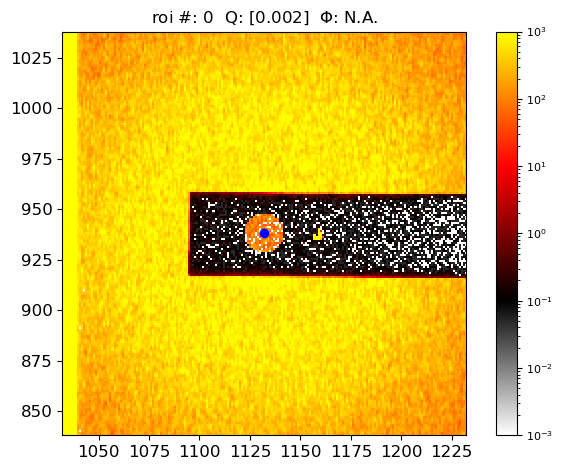

In [16]:
show_img( avg_img*nroi_mask,  vmin = .001, vmax = 1000, logs=True, aspect=1, #save_format='tif',
         image_name='roi #: %s  Q: %s  $\Phi$: %s'%(roi_nr,np.round(Q,4),phi_str) ,  save=False, path=None, cmap=cmap_albula,center=center)
extend=200
plt.xlim(center[0]-extend/2,center[0]+extend/2,);plt.ylim(center[1]-extend/2,center[1]+extend/2,)

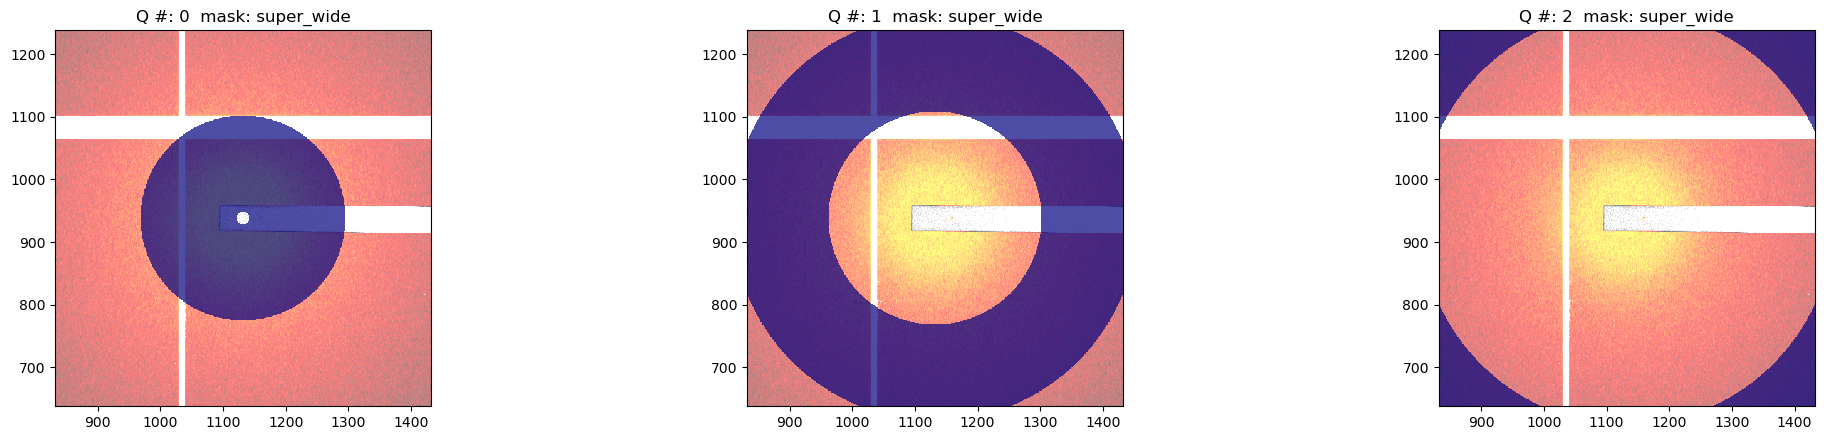

In [18]:
Q_nr=[0,1,2,]
extend=600 # show region of extend x extend pixels around center

##################################################################################
nrows=int(np.ceil(len(Q_nr)/3))
fig,ax=plt.subplots(nrows,3,figsize=(22,nrows*4.5))


for i,q_nr in enumerate(Q_nr):
    sum_mask=np.zeros(np.shape(avg_img))*np.nan
    plt.subplot(nrows,3,1+i)
    if geometry == 'ang_saxs':
        for phi_ in mask_param_dict[mask_selection]['ang_centers']:
            try:
                [roi_nr,Q,phi,Q_list,phi_list]=get_roi_nr(qval_dict,q=q_nr,phi=phi_,q_nr=True, phi_nr=False, q_thresh=1E-4, p_thresh=3, silent=True)
                #print('roi #: %s  Q: %s    Phi: %s'%(roi_nr,Q,phi))
                ind = roi_mask==roi_nr+1
                sum_mask[ind]=phi_
            except:
                pass
    elif geometry == 'saxs':
        ind = roi_mask==q_nr+1
        sum_mask[ind]=q_nr+1
    avg_img_=deepcopy(avg_img)
    ind=avg_img>np.max(avg_img[:,5])*.9
    avg_img_[ind]=np.nan
    plt.imshow(avg_img_,norm='log',vmin=.1,vmax=1000,cmap = cmap_albula,alpha=.5)
    # cm='viridis'
    # cm='Spectral'
    cm='jet'
    plt.imshow(sum_mask,cmap=cm,alpha=.7)
    if geometry =='ang_saxs':
        plt.colorbar(ticks=mask_param_dict[mask_selection]['ang_centers'],label='$\Phi$-centers [deg.]')

    plt.xlim(center[0]-extend/2,center[0]+extend/2,);plt.ylim(center[1]-extend/2,center[1]+extend/2,)
    plt.title('Q #: %s  mask: %s'%(q_nr,mask_selection))
    pc=i+1
for i in range(pc+1,nrows*3+1):
    plt.subplot(nrows,3,i);plt.axis('off')
plt.tight_layout()


In [ ]:
if False:
    # create .json filename
    roi_mask_path=_mask_path_+'ROI_masks/'
    roi_maskname='general_roi_mask_'+mask_selection+'.json'
    json_file=roi_mask_path+roi_maskname
    if not os.path.isfile(json_file): #roi_maskfle doesn't exist already -> good to save!
        save_dict={};save_dict['roi maskname']=mask_selection
        for k in list(mask_param_dict[mask_selection]):
            if type(mask_param_dict[mask_selection][k]) == type(np.array([])):
                save_dict[k]=mask_param_dict[mask_selection][k].tolist()
            else:
                save_dict[k]=mask_param_dict[mask_selection][k]
        save_dict['roi_mask']=roi_mask0.tolist()
        with open(json_file, "w") as outfile:
            json.dump(json.dumps(save_dict), outfile)
        print(colored('SAVED current ROI mask as %s'%json_file,'green'))
    else:
        print(colored('ERROR: file %s already exist, cannot overwrite it as it might be used by many users...'%json_file,'red'))

In [ ]:
_STOP:_the_END

In [ ]:
### How to load ROI-mask
# f = open(json_file)  ### load json file
# tmp = json.load(f);f.close()
# mask_dict=json.loads(tmp);del tmp
# mask_dict['roi_mask']=np.array(mask_dict['roi_mask'])

### saving current mask in legacy format (.npy) and in legacy location

In [ ]:
if False:
    # create .npy filename
    legacy_maskfile_path = '/nsls2/data/chx/shared/masks/'
    npy_file = legacy_maskfile_path+'general_roi_mask_'+mask_selection+'.npy'
    if not os.path.isfile(npy_file): #roi_maskfle doesn't exist already -> good to save!
        np.save(npy_file, roi_mask0)
        print('Saved mask %s as legacy mask %s'%(mask_selection,npy_file))
    else:
        print(colored('ERROR: file %s already exist, cannot overwrite it as it might be used by many...'%npy_file,'red'))

### saving legacy masks as json files [not all metadata is known...]

In [ ]:
legacy_mask_param_dict={'norm':
                 {'roi_maskname':'norm','flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':'unknown','gap_ring_number':'unknown','width':'unknown','edges':'unknown',
                 'ang_centers':'unknown','ang_width':'unknown',
                 'inner_angle':'unknown','outer_angle':'unknown','num_angles':'unknown','ROI mask size':8000,'original center':[4000,4000],'pixel_num_thres':'unknown','comment':'isotropic Q-mask without Phi-slicing, normal width rings, created from legacy .npy file'},
                 'wide':
                 {'roi_maskname':'wide','flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':'unknown','gap_ring_number':'unknown','width':'unknown','edges':'unknown',
                 'ang_centers':'unknown','ang_width':'unknown',
                 'inner_angle':'unknown','outer_angle':'unknown','num_angles':'unknown','ROI mask size':8000,'original center':[4000,4000],'pixel_num_thres':'unknown','comment':'isotropic Q-mask without Phi-slicing, wide rings, created from legacy .npy file'},
                'phi_12x_15deg_flow':
                 {'roi_maskname':'phi_12x15deg_flow','flow_geometry':True,'inner_radius':10,'outer_radius':4000,'num_rings':'unknown','gap_ring_number':'unknown','width':'unknown','edges':'unknown',
                 'ang_centers':'unknown','ang_width':'unknown',
                 'inner_angle':'unknown','outer_angle':'unknown','num_angles':'unknown','ROI mask size':8000,'original center':[4000,4000],'pixel_num_thres':'unknown','comment':'12x15deg mask for flow, created from legacy .npy file'},
                'phi_12x_30deg_flow':
                 {'roi_maskname':'phi_12x_30deg_flow','flow_geometry':True,'inner_radius':10,'outer_radius':4000,'num_rings':'unknown','gap_ring_number':'unknown','width':'unknown','edges':'unknown',
                 'ang_centers':'unknown','ang_width':'unknown',
                 'inner_angle':'unknown','outer_angle':'unknown','num_angles':'unknown','ROI mask size':8000,'original center':[4000,4000],'pixel_num_thres':'unknown','comment':'12x30deg mask for flow, created from legacy .npy file'},
                'phi_12x_30deg':
                 {'roi_maskname':'phi_12x_30deg','flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':'unknown','gap_ring_number':'unknown','width':'unknown','edges':'unknown',
                 'ang_centers':'unknown','ang_width':'unknown',
                 'inner_angle':'unknown','outer_angle':'unknown','num_angles':'unknown','ROI mask size':8000,'original center':[4000,4000],'pixel_num_thres':'unknown','comment':'12x30deg mask, created from legacy .npy file'},
                'phi_4x_20deg':
                 {'roi_maskname':'phi_4x_20deg','flow_geometry':False,'inner_radius':10,'outer_radius':4000,'num_rings':'unknown','gap_ring_number':'unknown','width':'unknown','edges':'unknown',
                 'ang_centers':'unknown','ang_width':'unknown',
                 'inner_angle':'unknown','outer_angle':'unknown','num_angles':'unknown','ROI mask size':8000,'original center':[4000,4000],'pixel_num_thres':'unknown','comment':'4x20deg mask, created from legacy .npy file'},
                
                       }

legacy_mask_path = _base_path_+'masks/' 

if False:
    for m in list(legacy_mask_param_dict.keys()):
        roi_maskname='general_roi_mask_'+m+'.json'
        json_file=roi_mask_path+roi_maskname
        save_dict=legacy_mask_param_dict[m]
        lm = np.load(legacy_mask_path+'general_roi_mask_%s.npy'%m)
        save_dict['roi_mask']=lm.tolist()
        del lm
        if not os.path.isfile(json_file): #roi_maskfle doesn't exist already -> good to save!
            with open(json_file, "w") as outfile:
                json.dump(json.dumps(save_dict), outfile)
            print(colored('SAVED current ROI mask as %s'%json_file,'green'))
        else:
            print(colored('ERROR: file %s already exist, cannot overwrite it as it might be used by many...'%json_file,'red'))